In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression,RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("Employee-Attrition.csv")

In [3]:
df.sample(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
524,34,No,Travel_Rarely,1442,Research & Development,9,3,Medical,1,717,...,2,80,0,9,3,4,8,7,7,7
392,54,No,Travel_Rarely,821,Research & Development,5,2,Medical,1,522,...,3,80,1,24,4,2,4,2,1,2
205,29,Yes,Travel_Rarely,121,Sales,27,3,Marketing,1,283,...,4,80,3,10,3,2,10,4,1,9
734,22,No,Travel_Rarely,217,Research & Development,8,1,Life Sciences,1,1019,...,1,80,1,4,3,2,4,3,1,1
248,37,No,Travel_Rarely,1017,Research & Development,1,2,Medical,1,340,...,1,80,1,17,2,2,3,1,0,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df.dropna()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [6]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


EDA


<Axes: xlabel='Gender', ylabel='count'>

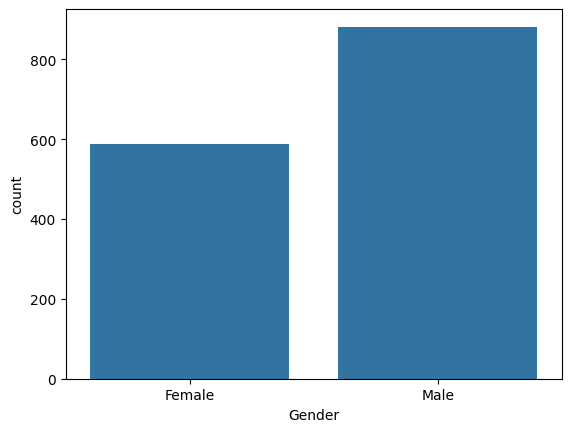

In [7]:
sns.countplot(data = df,x= 'Gender')

In [8]:
# The company has more male employees.

<Axes: xlabel='Gender', ylabel='count'>

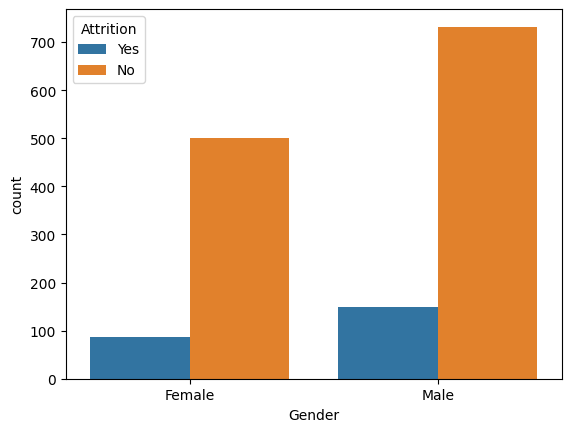

In [9]:
sns.countplot(data = df, x = 'Gender',hue = 'Attrition' )

In [10]:
# Attrition exists in both genders, slightly higher in males.
# But gender alone does not show a very strong difference in attrition — rates are fairly close.

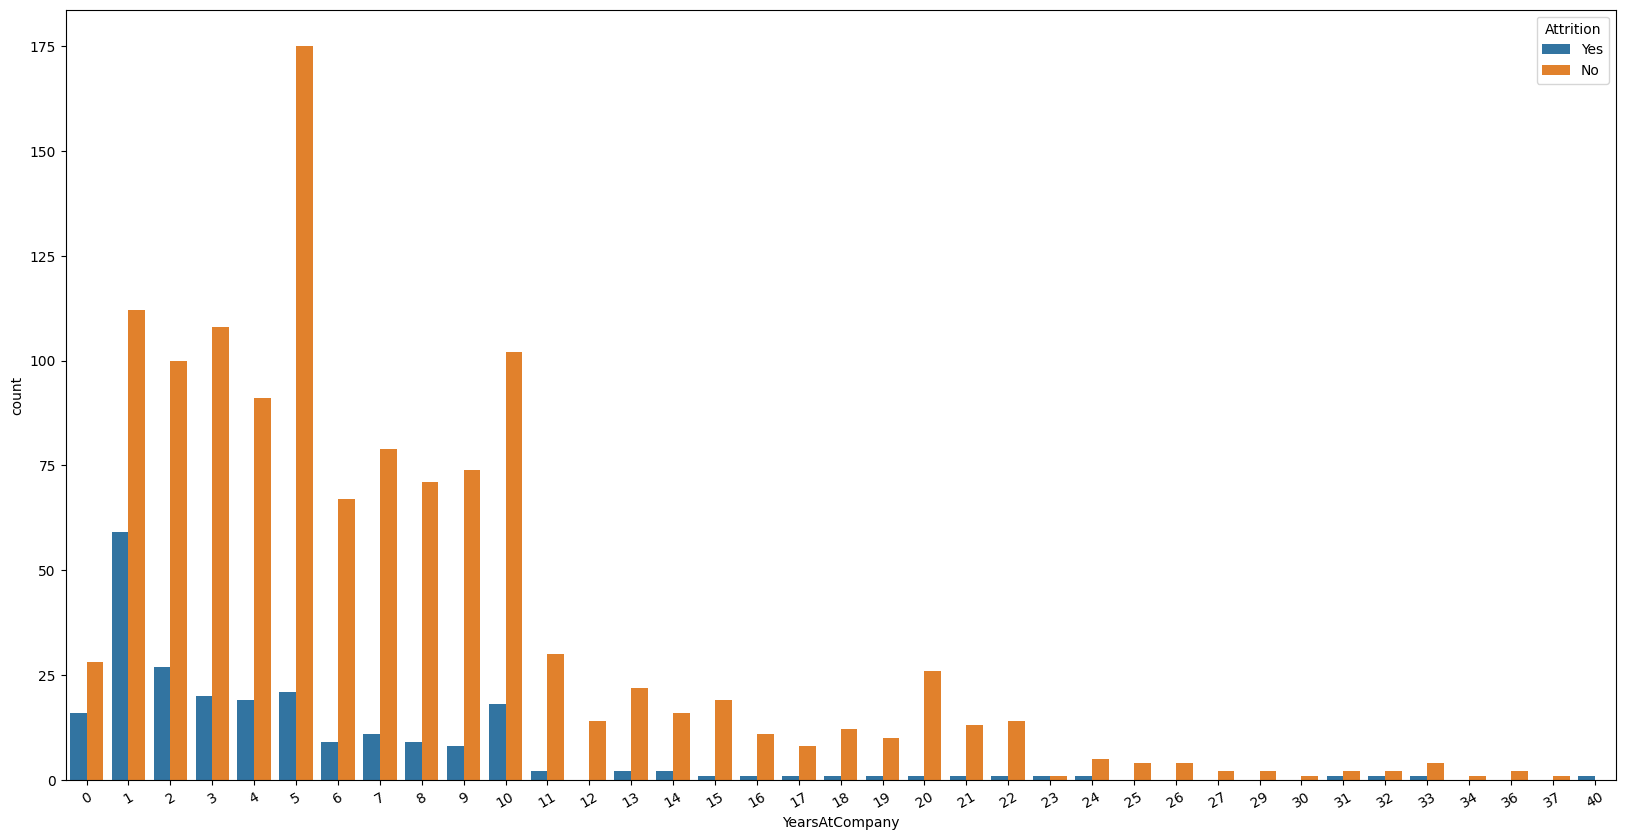

In [11]:
plt.figure(figsize=(20,10))
sns.countplot(data=df, x='YearsAtCompany', hue='Attrition')
plt.xticks(rotation=30)
plt.show()

In [12]:
# Most Attrition rate is in the 1st year of joining only while as year at company increases the attrition rate goes down means experienced have lesss probabidlity of leaving the company.

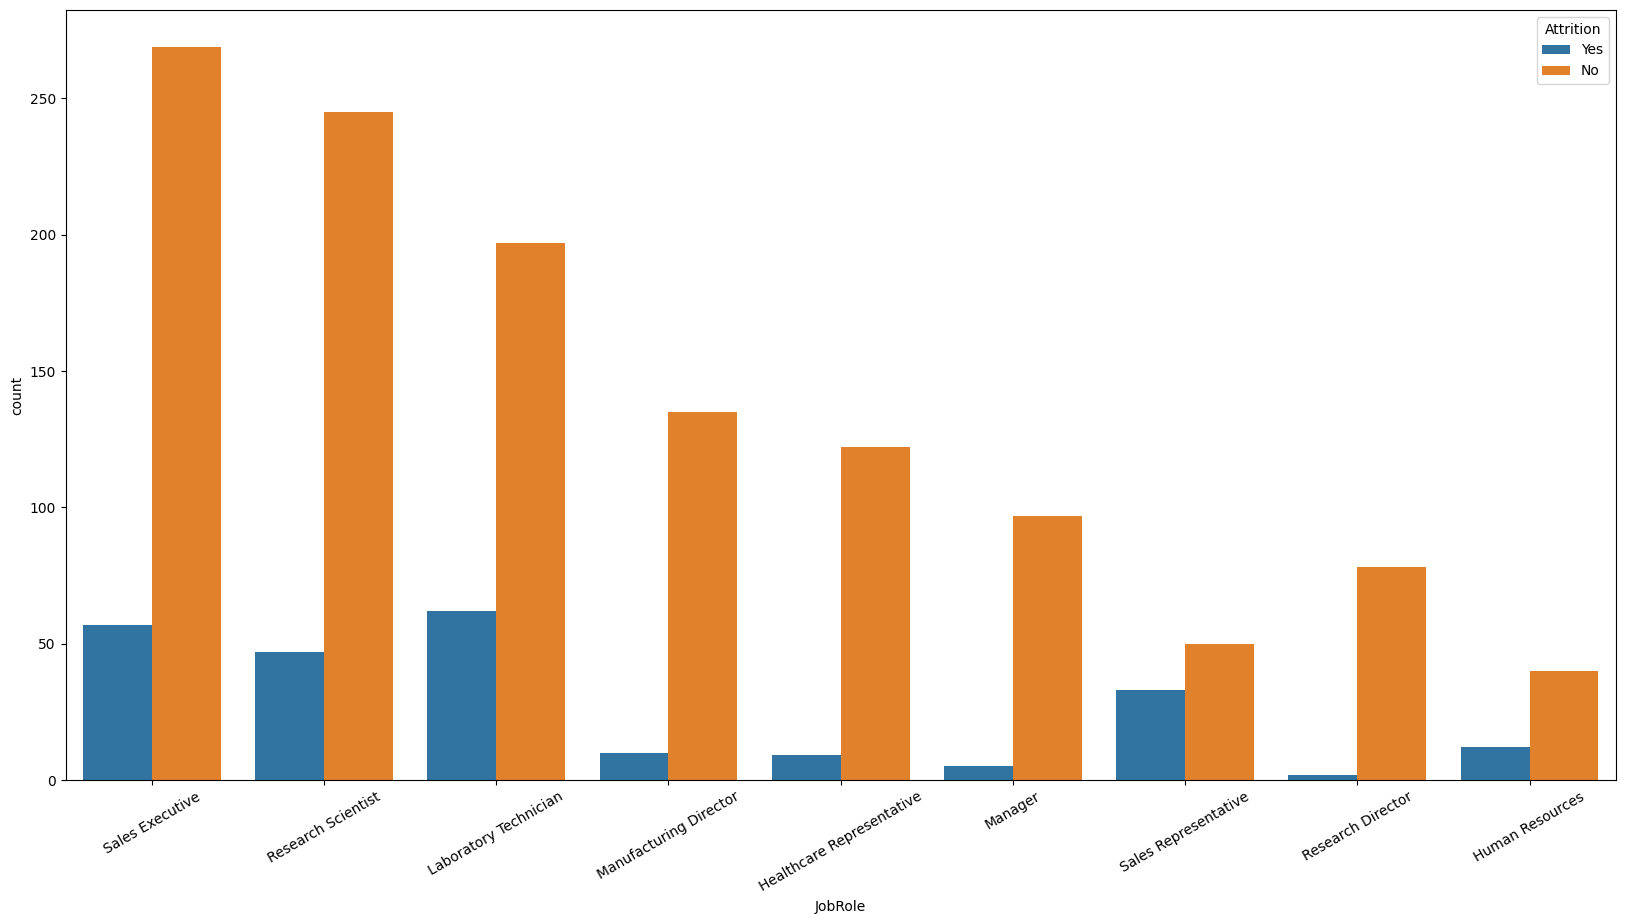

In [13]:
plt.figure(figsize=(20,10))
sns.countplot(data=df, x='JobRole', hue='Attrition')
plt.xticks(rotation=30)
plt.show()

In [14]:
# most attriton rate was in sales executive jobrole    and lowest was in research role

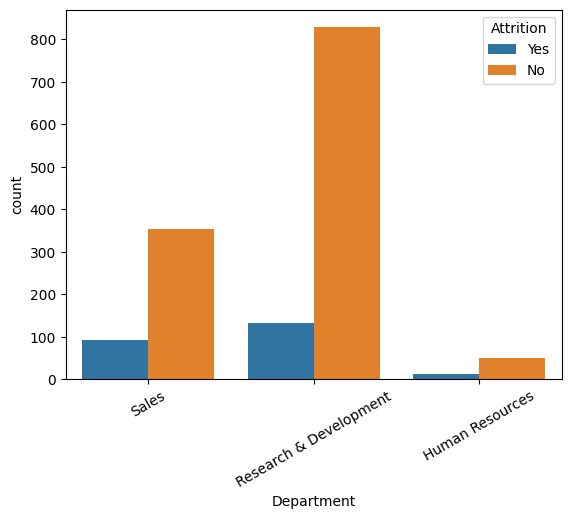

In [15]:
sns.countplot(data=df, x='Department', hue='Attrition')
plt.xticks(rotation=30)
plt.show()

In [16]:
#dept wise attrition least in human resource dept while most in research

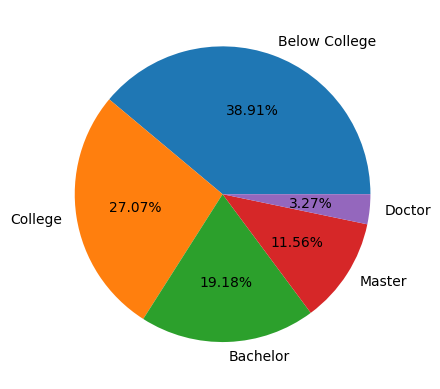

In [17]:
plt.pie(df['Education'].value_counts(),labels=[	'Below College','College','Bachelor','Master','Doctor'],autopct='%1.2f%%')
plt.show()


In [18]:
# most person working are below college

<Axes: ylabel='count'>

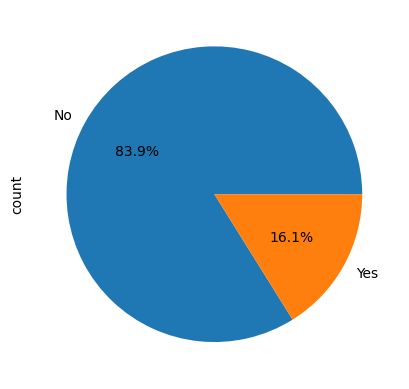

In [19]:
df['Attrition'].value_counts().plot.pie(autopct='%1.1f%%')

<Axes: ylabel='count'>

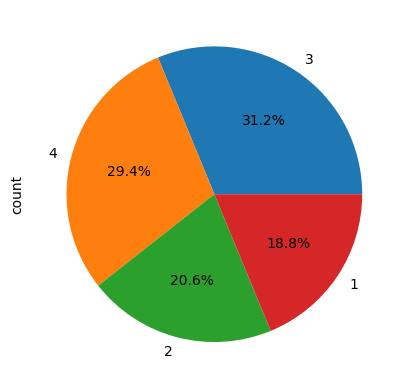

In [20]:
df['RelationshipSatisfaction'].value_counts().plot.pie(autopct='%1.1f%%')

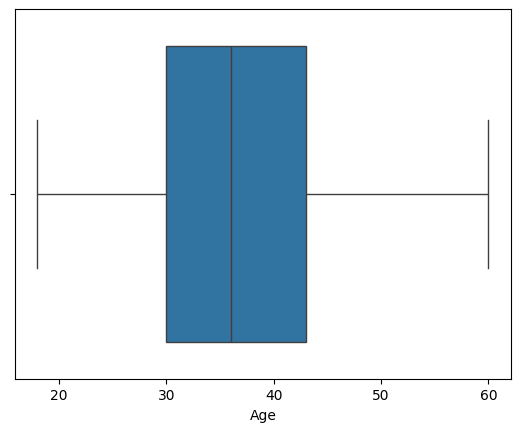

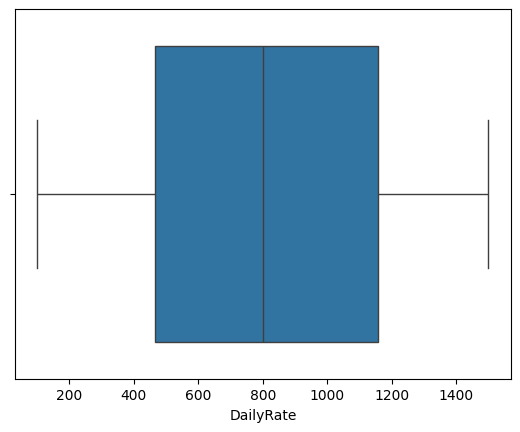

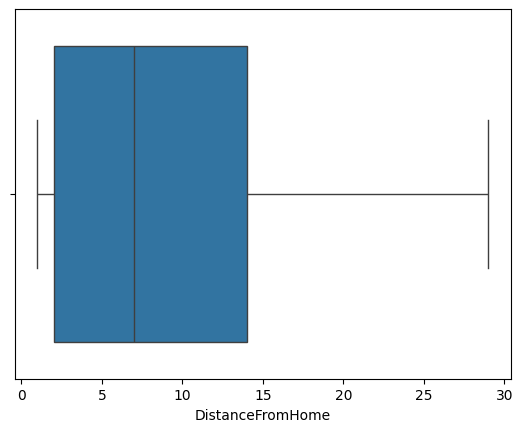

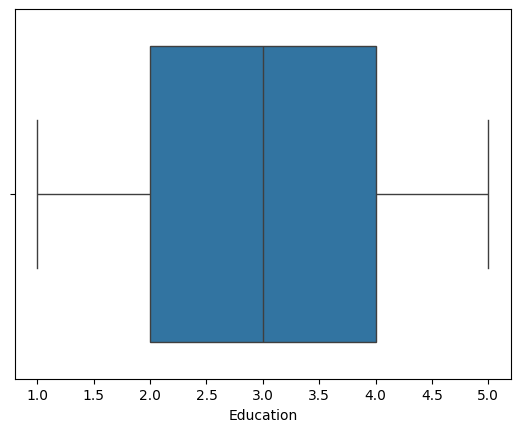

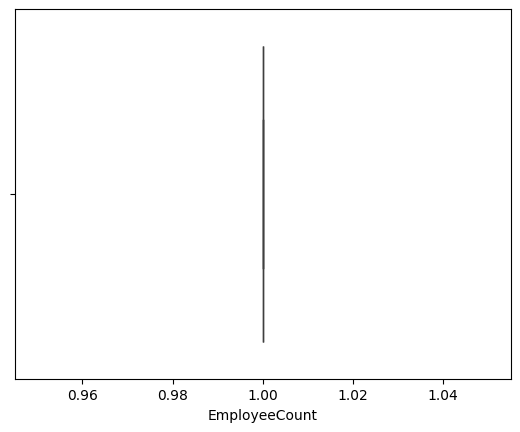

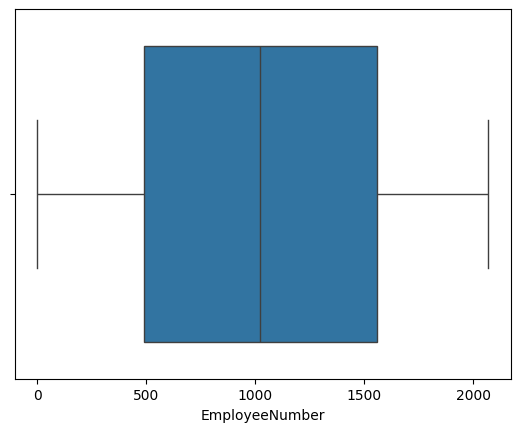

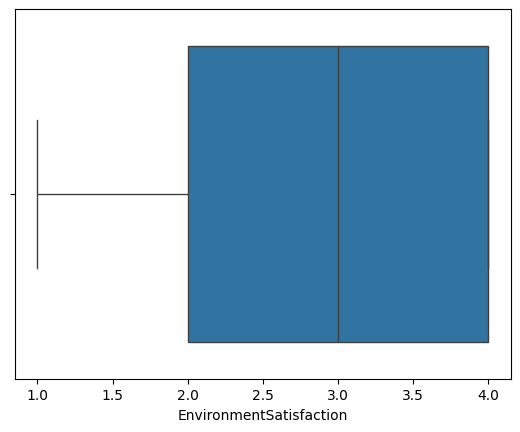

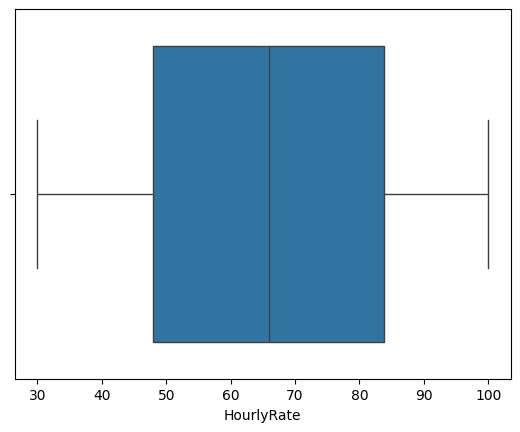

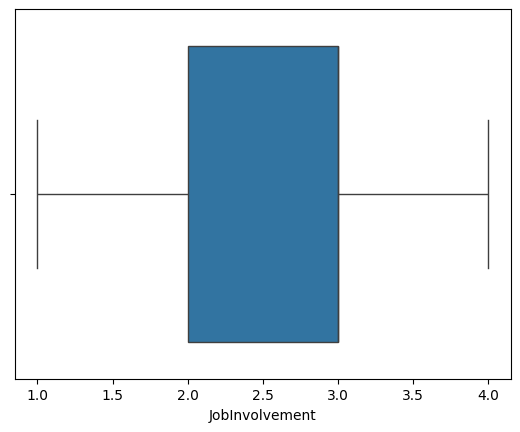

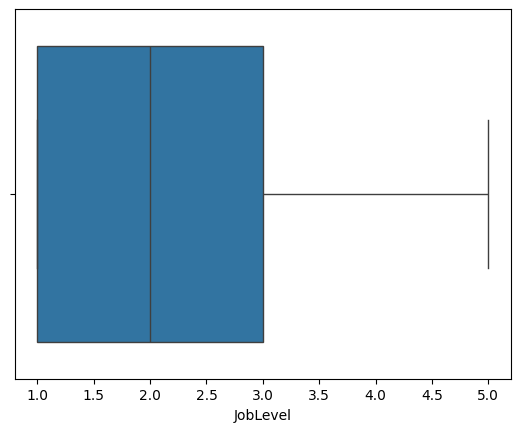

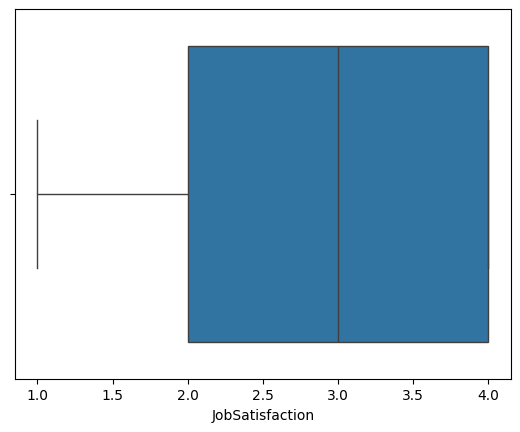

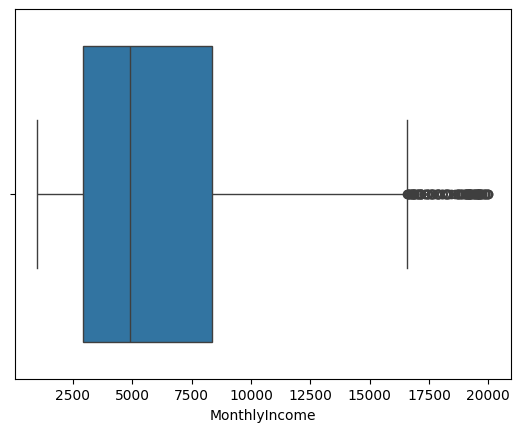

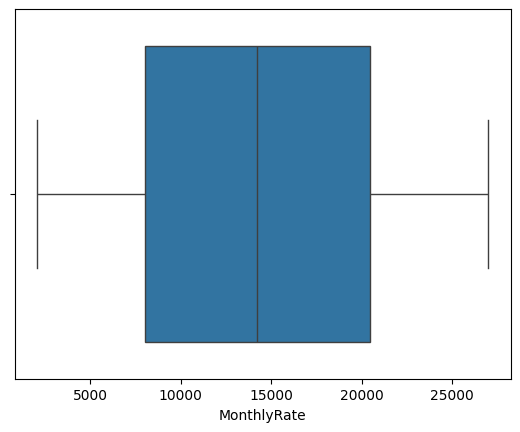

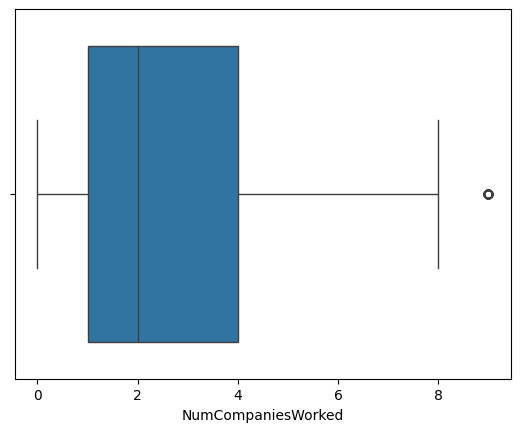

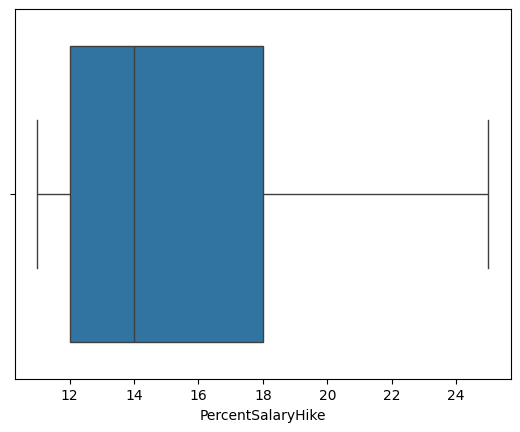

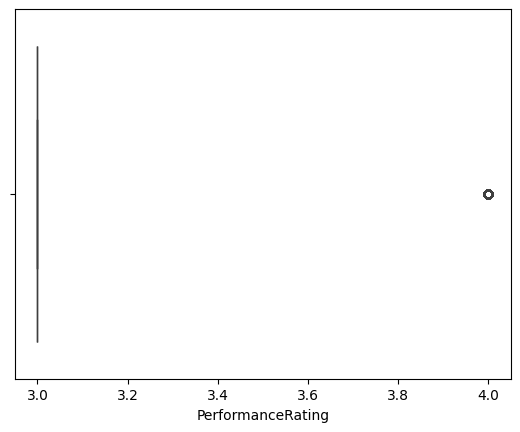

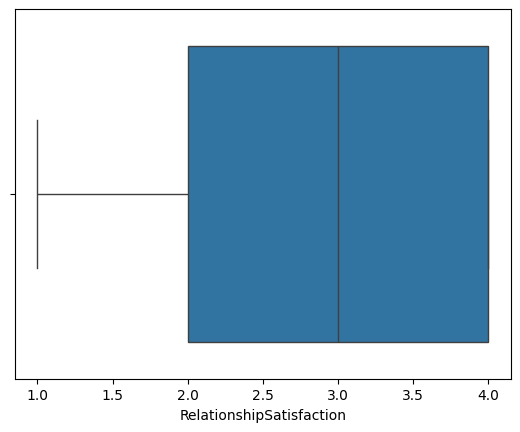

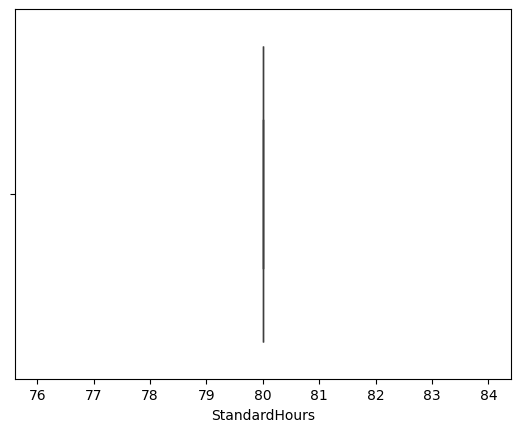

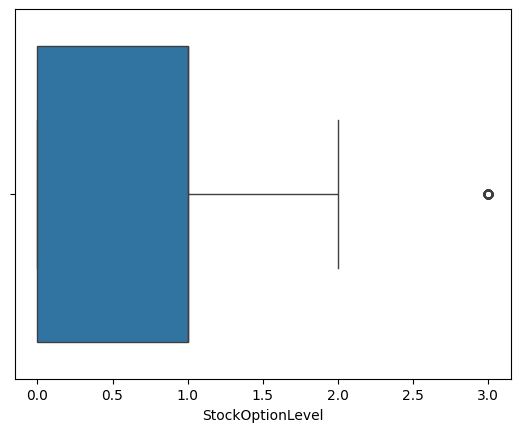

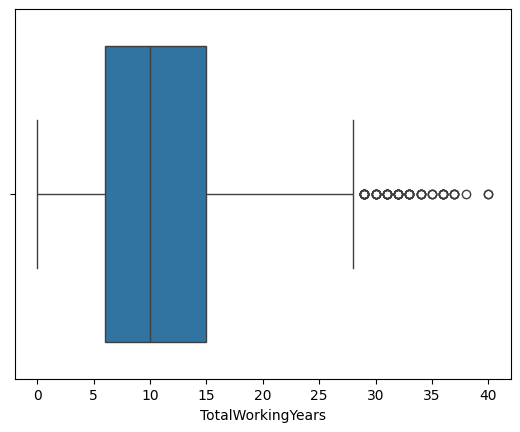

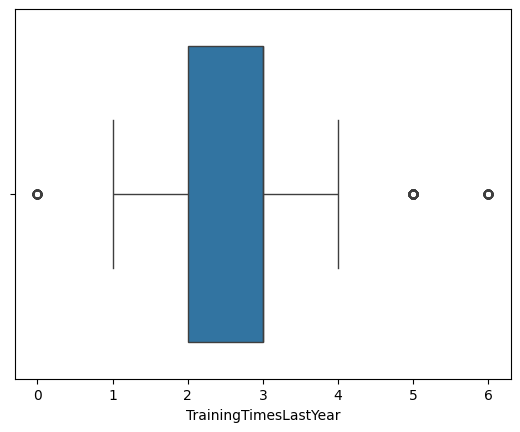

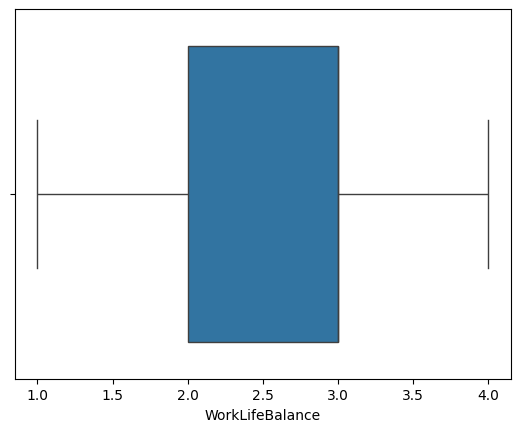

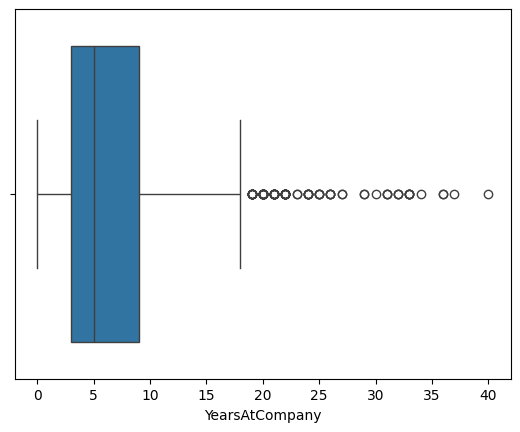

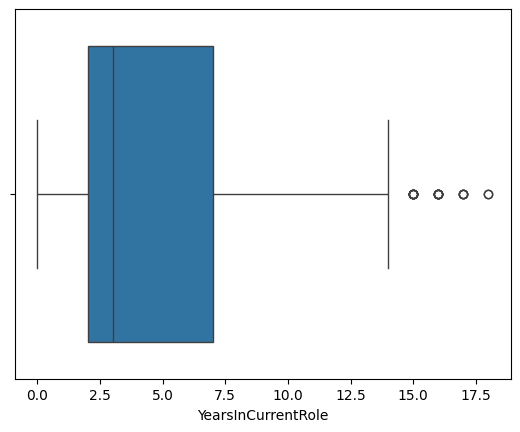

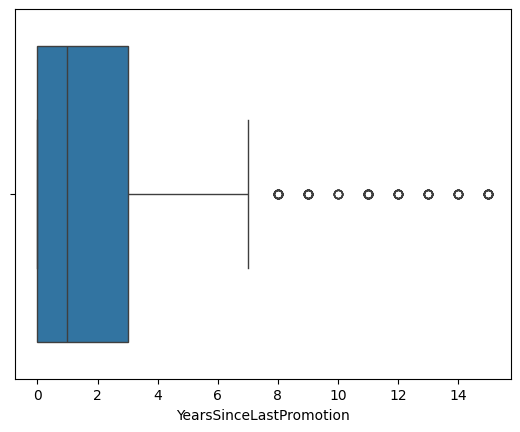

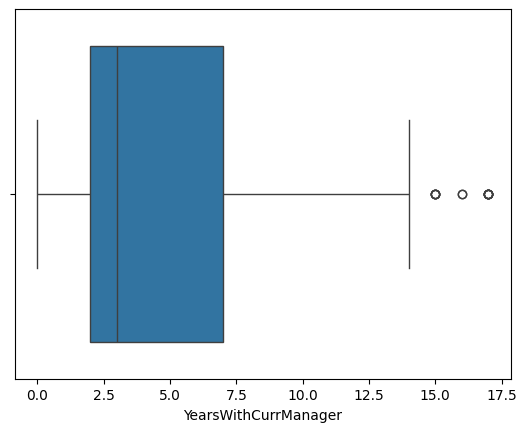

In [21]:
for col in df.select_dtypes(include='int64').columns:
    sns.boxplot(x=df[col])
    plt.show()

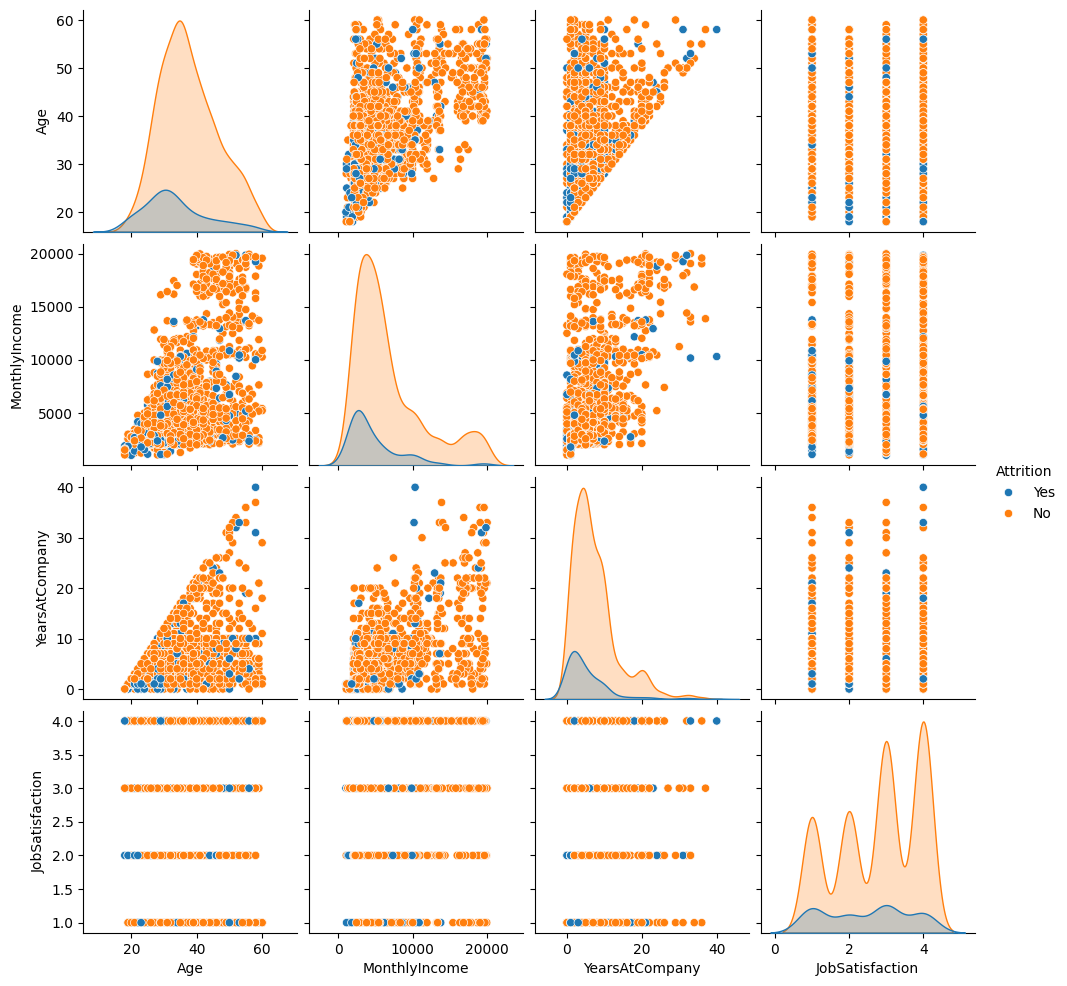

In [22]:
sns.pairplot(df[["Age", "MonthlyIncome", "YearsAtCompany","JobSatisfaction", "Attrition"]],hue="Attrition")
plt.show()

In [23]:
# 1. Age vs Attrition
# People who leave (Yes) are mostly younger (around 20–35).
# Older employees (40+) mostly stay (No).
# Younger employees are more likely to leave.
# 2. YearsAtCompany vs Attrition
# High attrition is concentrated at low experience (0–5 years).
# Very few people leave after 10+ years.
#  New employees are the highest risk group.
# This is one of the strongest signals in the plot.
# 3. MonthlyIncome vs Attrition
# Leavers mostly fall in the lower income range.
# High-income employees rarely leave
#  Lower salary → higher chance of attrition.
# 4. JobSatisfaction vs Attrition
# Attrition is highest at JobSatisfaction = 1 or 2.
# Very few leavers at 3 or 4.
#  Low job satisfaction strongly increases attrition.

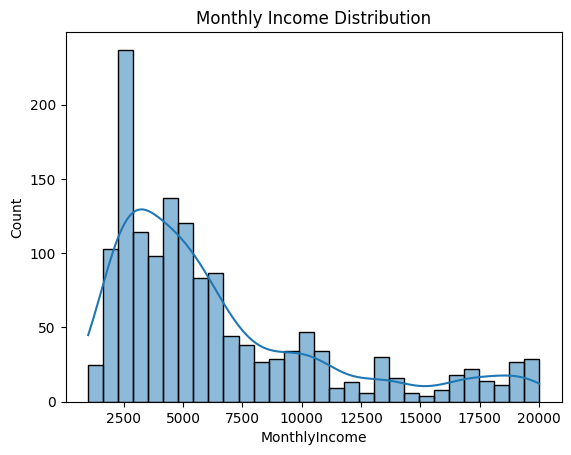

In [24]:
sns.histplot(df["MonthlyIncome"], bins=30, kde=True)
plt.title("Monthly Income Distribution")
plt.show()

In [25]:
for col in df.select_dtypes(include='object').columns:
    print(f"\tColumn: {col}")
    print(df[col].value_counts())


	Column: Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64
	Column: BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
	Column: Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
	Column: EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
	Column: Gender
Gender
Male      882
Female    588
Name: count, dtype: int64
	Column: JobRole
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int

In [26]:
drop_cols = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]
df = df.drop(columns=drop_cols)

In [27]:
df['Attrition'] = df['Attrition'].map({'No': 0, 'Yes': 1})
df['OverTime'] = df['OverTime'].map({'No': 0, 'Yes': 1})

In [28]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [29]:
cat_cols=['EducationField','JobRole','MaritalStatus','JobRole','EducationField','Department','BusinessTravel']
df=pd.get_dummies(df,columns=cat_cols,drop_first=True)
print(df.shape)

(1470, 58)


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 58 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EnvironmentSatisfaction            1470 non-null   int64
 6   Gender                             1470 non-null   int64
 7   HourlyRate                         1470 non-null   int64
 8   JobInvolvement                     1470 non-null   int64
 9   JobLevel                           1470 non-null   int64
 10  JobSatisfaction                    1470 non-null   int64
 11  MonthlyIncome                      1470 non-null   int64
 12  MonthlyRate         

In [31]:
df.replace({True: 1, False: 0}, inplace=True)


In [32]:
x = df.drop("Attrition", axis=1)
y = df["Attrition"]


In [33]:
print(y.isnull().sum())


0


In [34]:
sm = SMOTE(random_state=42)
x,y =sm.fit_resample(x,y)

In [35]:
std=StandardScaler()
std.fit(x)
Std_array=std.transform(x)
X_std=pd.DataFrame(Std_array,columns=x.columns)

In [36]:
x_train,x_test,y_train,y_test = train_test_split(X_std, y, test_size=0.2, random_state=42, stratify=y)

In [37]:
lr=LogisticRegression(max_iter=1000)
lr.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [38]:
print('***************** Testing Data Evaluation *********************')
y_pred = lr.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score :', accuracy)
print('**'*30)

cnf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix : \n', cnf_matrix)
print('**'*30)
clf_report = classification_report(y_test, y_pred)
print('Classification Report :\n', clf_report)

***************** Testing Data Evaluation *********************
Accuracy Score : 0.917004048582996
************************************************************
Confusion Matrix : 
 [[230  17]
 [ 24 223]]
************************************************************
Classification Report :
               precision    recall  f1-score   support

           0       0.91      0.93      0.92       247
           1       0.93      0.90      0.92       247

    accuracy                           0.92       494
   macro avg       0.92      0.92      0.92       494
weighted avg       0.92      0.92      0.92       494



In [ ]:
ridge_model = RidgeClassifier(alpha=0.1)
param_grid = {'alpha':np.linspace(0,100,100)}
gscv_ridge_model = GridSearchCV(ridge_model, param_grid, cv = 5)
gscv_ridge_model.fit(x_train, y_train)
gscv_ridge_model.best_estimator_

RidgeClassifier(alpha=np.float64(5.050505050505051))

In [ ]:
print('***************** Testing Data Evaluation *********************')
y_pred = gscv_ridge_model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score :', accuracy)
print('**'*30)

cnf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix : \n', cnf_matrix)
print('**'*30)
clf_report = classification_report(y_test, y_pred)
print('Classification Report :\n', clf_report)

***************** Testing Data Evaluation *********************
Accuracy Score : 0.9190283400809717
************************************************************
Confusion Matrix : 
 [[234  13]
 [ 27 220]]
************************************************************
Classification Report :
               precision    recall  f1-score   support

           0       0.90      0.95      0.92       247
           1       0.94      0.89      0.92       247

    accuracy                           0.92       494
   macro avg       0.92      0.92      0.92       494
weighted avg       0.92      0.92      0.92       494



In [ ]:
knn=KNeighborsClassifier(n_neighbors=10)
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=10)

In [ ]:
print('***************** Testing Data Evaluation *********************')
y_pred =knn.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score :', accuracy)
print('**'*30)

cnf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix : \n', cnf_matrix)
print('**'*30)
clf_report = classification_report(y_test, y_pred)
print('Classification Report :\n', clf_report)

***************** Testing Data Evaluation *********************
Accuracy Score : 0.9008097165991903
************************************************************
Confusion Matrix : 
 [[233  14]
 [ 35 212]]
************************************************************
Classification Report :
               precision    recall  f1-score   support

           0       0.87      0.94      0.90       247
           1       0.94      0.86      0.90       247

    accuracy                           0.90       494
   macro avg       0.90      0.90      0.90       494
weighted avg       0.90      0.90      0.90       494



In [ ]:
knn = KNeighborsClassifier()
h={'n_neighbors':np.arange(2,100),'p':(1,2)}
rscv=RandomizedSearchCV(knn,h,cv=5)
rscv.fit(x_train,y_train)
rscv.best_estimator_

KNeighborsClassifier(n_neighbors=np.int64(3), p=1)

In [ ]:
print('***************** Testing Data Evaluation *********************')
y_pred =rscv.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score :', accuracy)
print('**'*30)

cnf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix : \n', cnf_matrix)
print('**'*30)
clf_report = classification_report(y_test, y_pred)
print('Classification Report :\n', clf_report)

***************** Testing Data Evaluation *********************
Accuracy Score : 0.9109311740890689
************************************************************
Confusion Matrix : 
 [[222  25]
 [ 19 228]]
************************************************************
Classification Report :
               precision    recall  f1-score   support

           0       0.92      0.90      0.91       247
           1       0.90      0.92      0.91       247

    accuracy                           0.91       494
   macro avg       0.91      0.91      0.91       494
weighted avg       0.91      0.91      0.91       494



In [ ]:
accuracy_value = []

for k in range(2,30):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    accuracy_value.append(accuracy_score(y_test, knn.predict(x_test)))

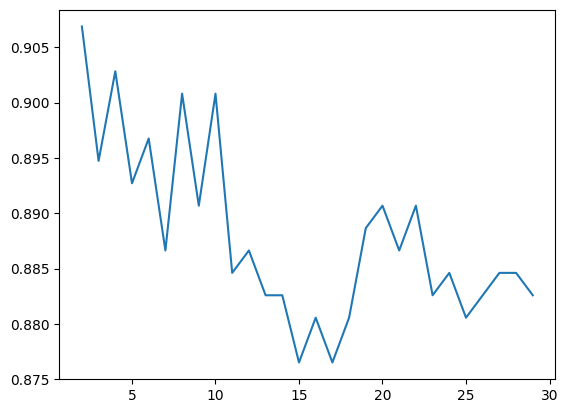

In [ ]:
plt.plot(range(2,30), accuracy_value)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

In [ ]:
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
print('***************** Testing Data Evaluation *********************')
y_pred =rscv.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score :', accuracy)
print('**'*30)

cnf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix : \n', cnf_matrix)
print('**'*30)
clf_report = classification_report(y_test, y_pred)
print('Classification Report :\n', clf_report)

***************** Testing Data Evaluation *********************
Accuracy Score : 0.5324324324324324
************************************************************
Confusion Matrix : 
 [[366   4]
 [342  28]]
************************************************************
Classification Report :
               precision    recall  f1-score   support

           0       0.52      0.99      0.68       370
           1       0.88      0.08      0.14       370

    accuracy                           0.53       740
   macro avg       0.70      0.53      0.41       740
weighted avg       0.70      0.53      0.41       740



In [ ]:
dt_clf = DecisionTreeClassifier(random_state=20)

hyp = {'criterion':['gini','entropy'],
    'splitter':['best','random'],
    'max_depth':np.arange(3,12),
    'min_samples_split': np.arange(5,20),
    'min_samples_leaf':np.arange(2,15) ,}

rscv_dt_clf =RandomizedSearchCV(dt_clf, hyp, cv=5)
rscv_dt_clf.fit(x_train, y_train)
rscv_dt_clf.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=np.int64(11),
                       min_samples_leaf=np.int64(3),
                       min_samples_split=np.int64(7), random_state=20,
                       splitter='random')

In [ ]:
print('***************** Testing Data Evaluation *********************')
y_pred =rscv_dt_clf.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score :', accuracy)
print('**'*30)

cnf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix : \n', cnf_matrix)
print('**'*30)
clf_report = classification_report(y_test, y_pred)
print('Classification Report :\n', clf_report)

***************** Testing Data Evaluation *********************
Accuracy Score : 0.8324324324324325
************************************************************
Confusion Matrix : 
 [[295  75]
 [ 49 321]]
************************************************************
Classification Report :
               precision    recall  f1-score   support

           0       0.86      0.80      0.83       370
           1       0.81      0.87      0.84       370

    accuracy                           0.83       740
   macro avg       0.83      0.83      0.83       740
weighted avg       0.83      0.83      0.83       740



In [ ]:
rf_model  = RandomForestClassifier(random_state=20)
rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=20)

In [ ]:
print('***************** Testing Data Evaluation *********************')
y_pred =rf_model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score :', accuracy)
print('**'*30)

cnf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix : \n', cnf_matrix)
print('**'*30)
clf_report = classification_report(y_test, y_pred)
print('Classification Report :\n', clf_report)

***************** Testing Data Evaluation *********************
Accuracy Score : 0.9202702702702703
************************************************************
Confusion Matrix : 
 [[347  23]
 [ 36 334]]
************************************************************
Classification Report :
               precision    recall  f1-score   support

           0       0.91      0.94      0.92       370
           1       0.94      0.90      0.92       370

    accuracy                           0.92       740
   macro avg       0.92      0.92      0.92       740
weighted avg       0.92      0.92      0.92       740



In [ ]:
rf_model  = RandomForestClassifier(random_state=20)
hyp = {'n_estimators':np.arange(10,200),
    'criterion':['gini','entropy'],
    'max_depth':np.arange(5,35),
    'min_samples_split':np.arange(5,20),
    'min_samples_leaf':np.arange(4,15),
    'max_features':['sqrt','log2']}
rscv_rf_clf = RandomizedSearchCV(rf_model, hyp, cv=5)
rscv_rf_clf.fit(x_train, y_train)
rscv_rf_clf.best_params_

{'n_estimators': np.int64(191),
 'min_samples_split': np.int64(11),
 'min_samples_leaf': np.int64(5),
 'max_features': 'log2',
 'max_depth': np.int64(20),
 'criterion': 'entropy'}

In [ ]:
print('***************** Testing Data Evaluation *********************')
y_pred =rscv_rf_clf.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score :', accuracy)
print('**'*30)

cnf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix : \n', cnf_matrix)
print('**'*30)
clf_report = classification_report(y_test, y_pred)
print('Classification Report :\n', clf_report)

***************** Testing Data Evaluation *********************
Accuracy Score : 0.8945945945945946
************************************************************
Confusion Matrix : 
 [[336  34]
 [ 44 326]]
************************************************************
Classification Report :
               precision    recall  f1-score   support

           0       0.88      0.91      0.90       370
           1       0.91      0.88      0.89       370

    accuracy                           0.89       740
   macro avg       0.89      0.89      0.89       740
weighted avg       0.89      0.89      0.89       740



In [ ]:
rf_model.feature_importances_

array([0.03218899, 0.03277323, 0.03152307, 0.01794511, 0.030635  ,
       0.01856004, 0.02728433, 0.04219041, 0.03504123, 0.03393335,
       0.0604584 , 0.03237398, 0.01705369, 0.00964517, 0.01946708,
       0.00380792, 0.03314902, 0.06029956, 0.03711369, 0.01817555,
       0.02015325, 0.029236  , 0.02694676, 0.01863371, 0.03206266,
       0.0166056 , 0.00477543, 0.01858843, 0.00550364, 0.00769622,
       0.00553   , 0.00569309, 0.00283268, 0.00374197, 0.00181338,
       0.00855051, 0.0061957 , 0.0020657 , 0.0294177 , 0.00907404,
       0.00318859, 0.00374337, 0.00354855, 0.00476852, 0.00123054,
       0.00758633, 0.00417788, 0.00239212, 0.01962108, 0.00558621,
       0.01967822, 0.00430703, 0.00658822, 0.03497346, 0.01086171,
       0.00450262, 0.01451025])

<Axes: >

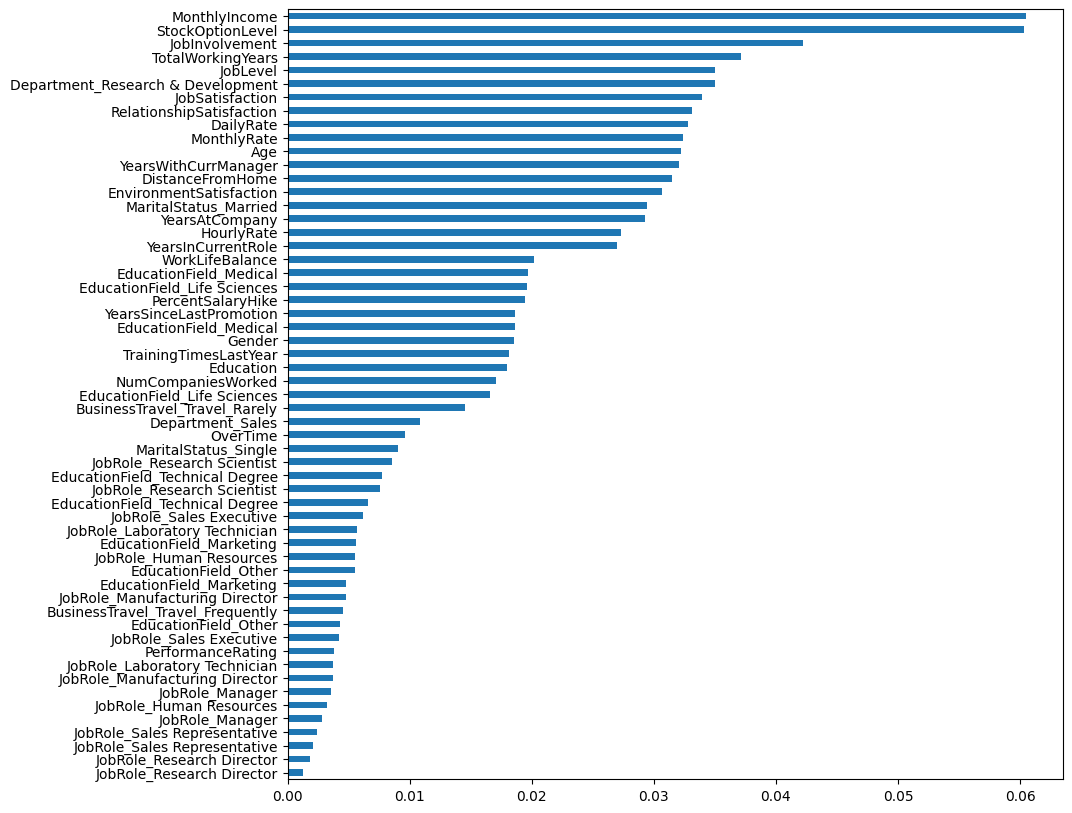

In [ ]:
plt.figure(figsize=(10,10))
s1 = pd.Series(rf_model.feature_importances_, index=x.columns)
s1.sort_values().plot(kind='barh')

In [ ]:
ada_boost = AdaBoostClassifier(n_estimators=7,random_state=60)
ada_boost.fit(x_train,y_train)

AdaBoostClassifier(n_estimators=7, random_state=60)

In [ ]:
print('***************** Testing Data Evaluation *********************')
y_pred =ada_boost.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score :', accuracy)
print('**'*30)

cnf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix : \n', cnf_matrix)
print('**'*30)
clf_report = classification_report(y_test, y_pred)
print('Classification Report :\n', clf_report)

***************** Testing Data Evaluation *********************
Accuracy Score : 0.7635135135135135
************************************************************
Confusion Matrix : 
 [[266 104]
 [ 71 299]]
************************************************************
Classification Report :
               precision    recall  f1-score   support

           0       0.79      0.72      0.75       370
           1       0.74      0.81      0.77       370

    accuracy                           0.76       740
   macro avg       0.77      0.76      0.76       740
weighted avg       0.77      0.76      0.76       740



In [ ]:
adb_model = AdaBoostClassifier(random_state=20)
hyp_grid = {'n_estimators': np.arange(10,50),
           'learning_rate':np.arange(0.01, 2, 0.01)}

rscv_adb_clf = RandomizedSearchCV(adb_model, hyp_grid, cv=7, random_state= 10)
rscv_adb_clf.fit(x_train,y_train)
rscv_adb_clf.best_estimator_

AdaBoostClassifier(learning_rate=np.float64(1.1600000000000001),
                   n_estimators=np.int64(33), random_state=20)

In [ ]:
print('***************** Testing Data Evaluation *********************')
y_pred =rscv_adb_clf.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score :', accuracy)
print('**'*30)

cnf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix : \n', cnf_matrix)
print('**'*30)
clf_report = classification_report(y_test, y_pred)
print('Classification Report :\n', clf_report)


***************** Testing Data Evaluation *********************
Accuracy Score : 0.8472972972972973
************************************************************
Confusion Matrix : 
 [[310  60]
 [ 53 317]]
************************************************************
Classification Report :
               precision    recall  f1-score   support

           0       0.85      0.84      0.85       370
           1       0.84      0.86      0.85       370

    accuracy                           0.85       740
   macro avg       0.85      0.85      0.85       740
weighted avg       0.85      0.85      0.85       740



In [ ]:
bag = BaggingClassifier(estimator= SVC(), n_estimators=10, random_state=42, oob_score=True)
bag.fit(x_train, y_train)

BaggingClassifier(estimator=SVC(), oob_score=True, random_state=42)

In [ ]:
print('***************** Testing Data Evaluation *********************')
y_pred =bag.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score :', accuracy)
print('**'*30)

cnf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix : \n', cnf_matrix)
print('**'*30)
clf_report = classification_report(y_test, y_pred)
print('Classification Report :\n', clf_report)

***************** Testing Data Evaluation *********************
Accuracy Score : 0.9149797570850202
************************************************************
Confusion Matrix : 
 [[240   7]
 [ 35 212]]
************************************************************
Classification Report :
               precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.97      0.86      0.91       247

    accuracy                           0.91       494
   macro avg       0.92      0.91      0.91       494
weighted avg       0.92      0.91      0.91       494



In [ ]:
clf1 = LogisticRegression( random_state=22,max_iter=1000)
clf2 = KNeighborsClassifier(n_neighbors=5)
clf4 = SVC()

models = [('Lr', clf1),('knn', clf2), ('svc', clf4)]
voting = VotingClassifier(estimators=models, voting='hard')
voting.fit(x_train, y_train)

VotingClassifier(estimators=[('Lr',
                              LogisticRegression(max_iter=1000,
                                                 random_state=22)),
                             ('knn', KNeighborsClassifier()), ('svc', SVC())])

In [ ]:
y_pred = voting.predict(x_test)

cnf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix :\n', cnf_matrix)

acc_score = accuracy_score(y_test, y_pred)
print('Accuracy :', acc_score)

clf_report = classification_report(y_test, y_pred)
print('Classification Report :\n', clf_report)

Confusion Matrix :
 [[239   8]
 [ 30 217]]
Accuracy : 0.9230769230769231
Classification Report :
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.96      0.88      0.92       247

    accuracy                           0.92       494
   macro avg       0.93      0.92      0.92       494
weighted avg       0.93      0.92      0.92       494



In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x  ,y,test_size=0.3,random_state=42,stratify=y)

In [ ]:
gnb_model = GaussianNB()
gnb_model.fit(x_train,y_train)

GaussianNB()

In [ ]:
print('***************** Testing Data Evaluation *********************')
y_pred =gnb_model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score :', accuracy)
print('**'*30)

cnf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix : \n', cnf_matrix)
print('**'*30)
clf_report = classification_report(y_test, y_pred)
print('Classification Report :\n', clf_report)

***************** Testing Data Evaluation *********************
Accuracy Score : 0.7418918918918919
************************************************************
Confusion Matrix : 
 [[214 156]
 [ 35 335]]
************************************************************
Classification Report :
               precision    recall  f1-score   support

           0       0.86      0.58      0.69       370
           1       0.68      0.91      0.78       370

    accuracy                           0.74       740
   macro avg       0.77      0.74      0.73       740
weighted avg       0.77      0.74      0.73       740



In [ ]:
bnb_model= BernoulliNB()
bnb_model.fit(x_train,y_train)

BernoulliNB()

In [ ]:
print('***************** Testing Data Evaluation *********************')
y_pred =bnb_model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score :', accuracy)
print('**'*30)

cnf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix : \n', cnf_matrix)
print('**'*30)
clf_report = classification_report(y_test, y_pred)
print('Classification Report :\n', clf_report)

***************** Testing Data Evaluation *********************
Accuracy Score : 0.8432432432432433
************************************************************
Confusion Matrix : 
 [[309  61]
 [ 55 315]]
************************************************************
Classification Report :
               precision    recall  f1-score   support

           0       0.85      0.84      0.84       370
           1       0.84      0.85      0.84       370

    accuracy                           0.84       740
   macro avg       0.84      0.84      0.84       740
weighted avg       0.84      0.84      0.84       740



In [ ]:
std=StandardScaler()
std.fit(x)
Std_array=std.transform(x)
X_std=pd.DataFrame(Std_array,columns=x.columns)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(X_std,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
svc_model = SVC()
svc_model.fit(x_train,y_train)

SVC()

In [ ]:
print('***************** Testing Data Evaluation *********************')
y_pred =svc_model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score :', accuracy)
print('**'*30)

cnf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix : \n', cnf_matrix)
print('**'*30)
clf_report = classification_report(y_test, y_pred)
print('Classification Report :\n', clf_report)

***************** Testing Data Evaluation *********************
Accuracy Score : 0.9149797570850202
************************************************************
Confusion Matrix : 
 [[241   6]
 [ 36 211]]
************************************************************
Classification Report :
               precision    recall  f1-score   support

           0       0.87      0.98      0.92       247
           1       0.97      0.85      0.91       247

    accuracy                           0.91       494
   macro avg       0.92      0.91      0.91       494
weighted avg       0.92      0.91      0.91       494



From the model evaluation results, Random Forest is selected as the best base model. Although the Voting Classifier shows a slightly higher accuracy, the improvement is only about 0.28%, which is marginal and not significant enough to outweigh the advantages of Random Forest. Additionally, the Voting Classifier does not provide feature importance, whereas Random Forest offers feature importance scores that help in feature selection and model interpretability. This is especially useful for reducing the number of input features and improving user experience.

Another reason for choosing Random Forest is that it combines multiple decision trees, making it well-suited for the employee attrition dataset, where predictions depend on multiple conditions and complex relationships between features.

The KNN model was not selected despite good performance because it has several practical limitations: it becomes slow during prediction on large datasets since it calculates distances to all neighbors, it is sensitive to feature scaling, and it is highly affected by irrelevant features. These factors make it less suitable for deployment in this scenario.

In [39]:
cols = ['MonthlyIncome', 'StockOptionLevel', 'JobInvolvement',
       'TotalWorkingYears', 'JobLevel', 'JobSatisfaction',
       'RelationshipSatisfaction', 'DailyRate', 'MonthlyRate', 'Age',
       'DistanceFromHome', 'EnvironmentSatisfaction',
       'YearsWithCurrManager','Attrition']
df2 = df[cols].copy()
df2

,MonthlyIncome,StockOptionLevel,JobInvolvement,TotalWorkingYears,JobLevel,JobSatisfaction,RelationshipSatisfaction,DailyRate,MonthlyRate,Age,DistanceFromHome,EnvironmentSatisfaction,YearsWithCurrManager,Attrition
0,5993,0,3,8,2,4,1,1102,19479,41,1,2,5,1
1,5130,1,2,10,2,2,4,279,24907,49,8,3,7,0
2,2090,0,2,7,1,3,2,1373,2396,37,2,4,0,1
3,2909,0,3,8,1,3,3,1392,23159,33,3,4,0,0
4,3468,1,3,6,1,2,4,591,16632,27,2,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,2571,1,4,17,2,4,3,884,12290,36,23,3,3,0
1466,9991,1,2,9,3,1,1,613,21457,39,6,4,7,0
1467,6142,1,4,6,2,2,2,155,5174,27,4,2,3,0
1468,5390,0,2,17,2,2,4,1023,13243,49,2,4,8,0


In [40]:
df2.shape


(1470, 14)

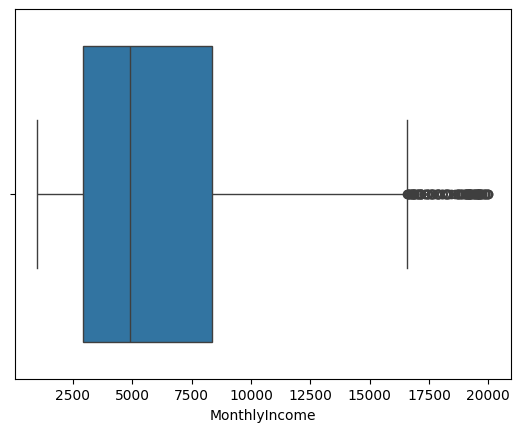

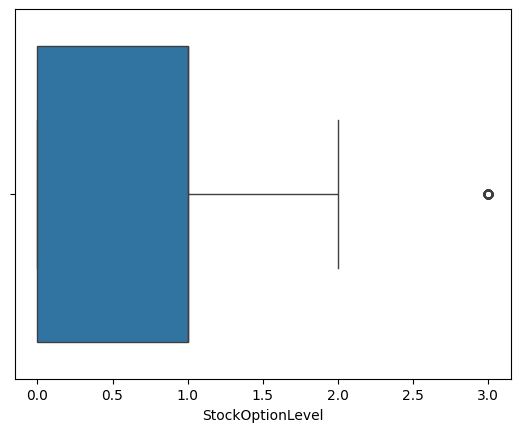

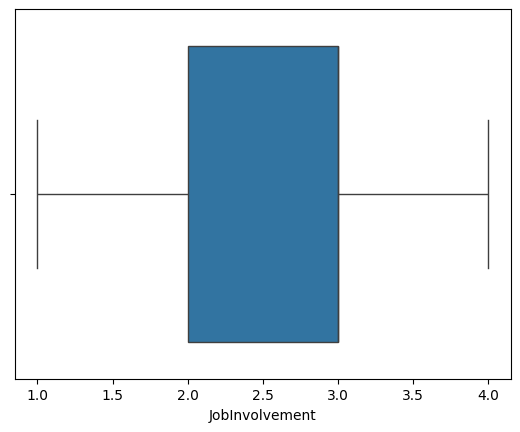

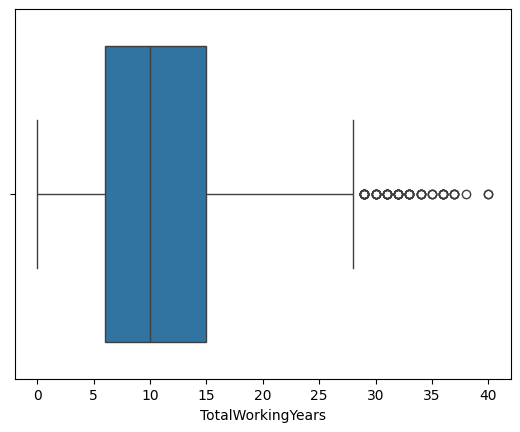

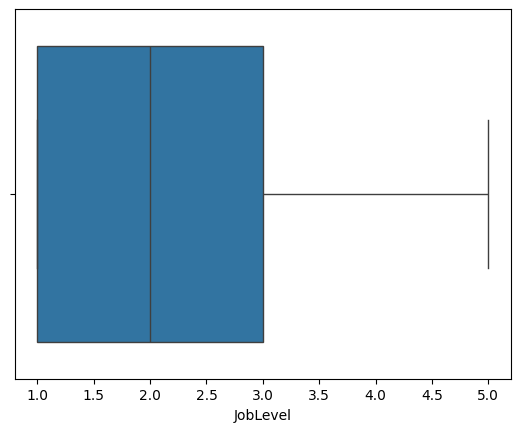

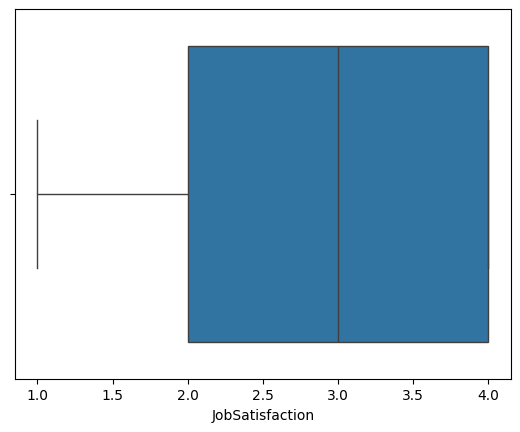

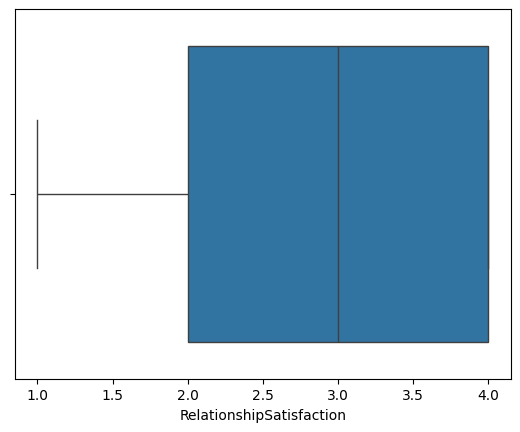

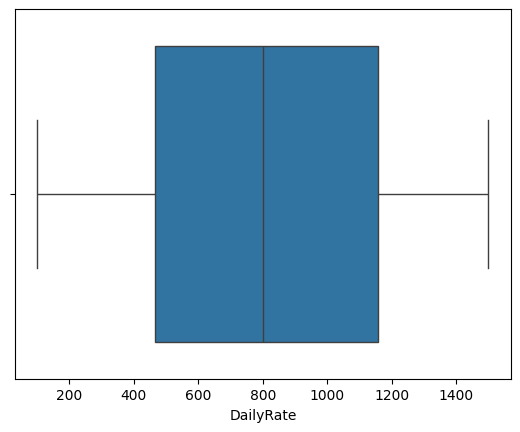

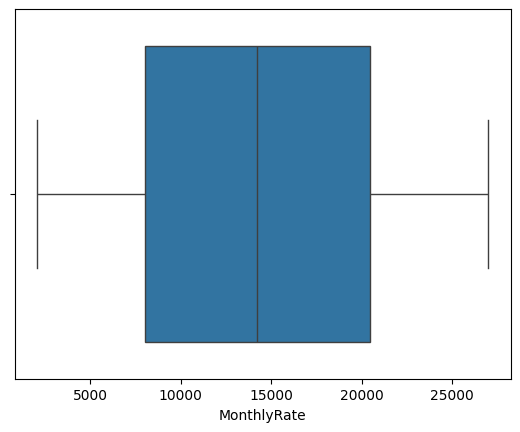

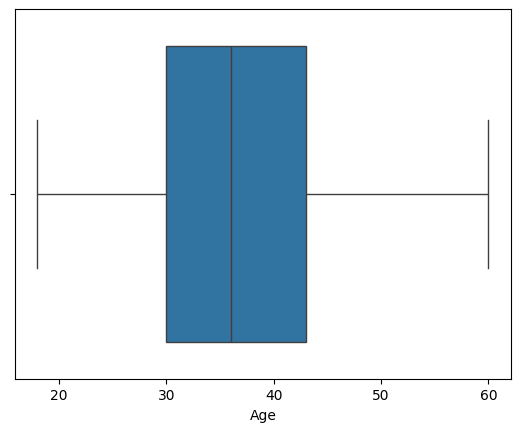

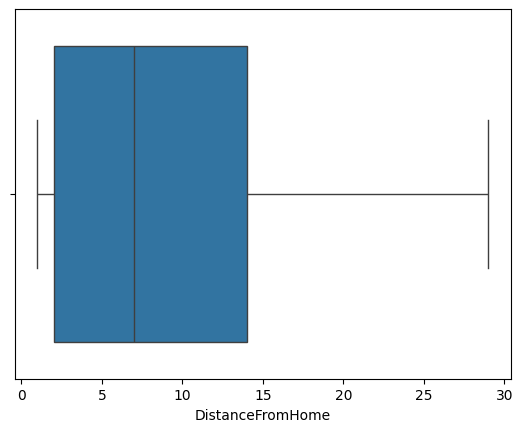

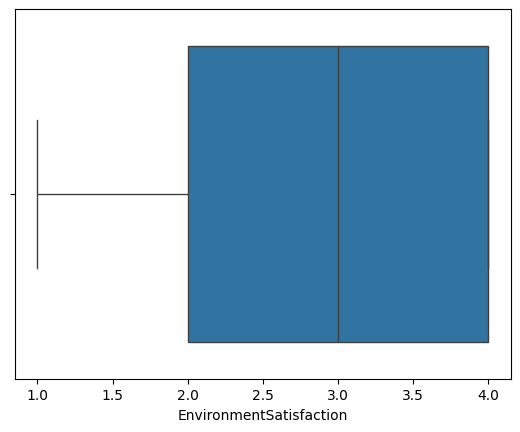

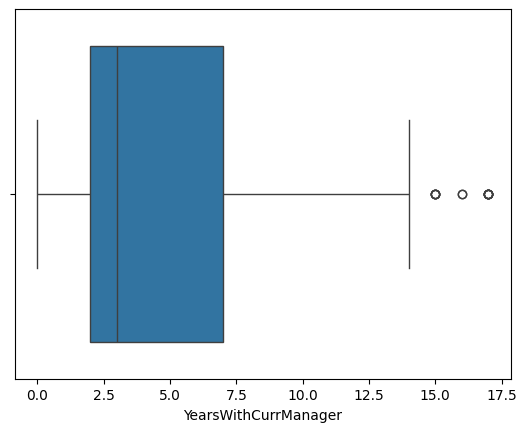

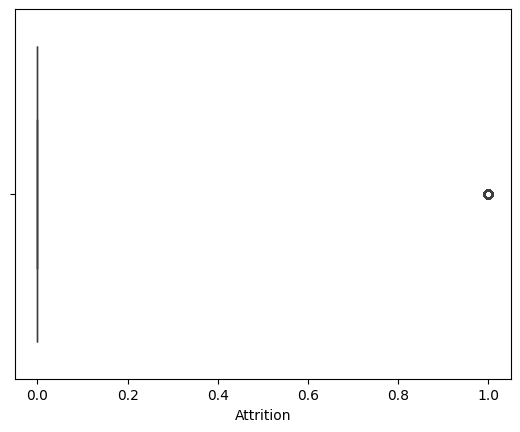

In [41]:
for col in df2.select_dtypes(include='int64').columns:
    sns.boxplot(x=df[col])
    plt.show()

In [42]:
df2["MonthlyIncome"] = np.log1p(df2["MonthlyIncome"])

In [43]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MonthlyIncome             1470 non-null   float64
 1   StockOptionLevel          1470 non-null   int64  
 2   JobInvolvement            1470 non-null   int64  
 3   TotalWorkingYears         1470 non-null   int64  
 4   JobLevel                  1470 non-null   int64  
 5   JobSatisfaction           1470 non-null   int64  
 6   RelationshipSatisfaction  1470 non-null   int64  
 7   DailyRate                 1470 non-null   int64  
 8   MonthlyRate               1470 non-null   int64  
 9   Age                       1470 non-null   int64  
 10  DistanceFromHome          1470 non-null   int64  
 11  EnvironmentSatisfaction   1470 non-null   int64  
 12  YearsWithCurrManager      1470 non-null   int64  
 13  Attrition                 1470 non-null   int64  
dtypes: float

In [44]:
x=df2.drop("Attrition",axis=1)
y=df2["Attrition"]

In [45]:
sm = SMOTE(random_state=42)
x,y =sm.fit_resample(x,y)

In [46]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,stratify=y,random_state=42)

In [47]:
rf=RandomForestClassifier(random_state=20)
rf.fit(x_train,y_train)

RandomForestClassifier(random_state=20)

In [48]:
print('***************** Testing Data Evaluation *********************')
y_pred =rf.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score :', accuracy)
print('**'*30)

cnf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix : \n', cnf_matrix)
print('**'*30)
clf_report = classification_report(y_test, y_pred)
print('Classification Report :\n', clf_report)

***************** Testing Data Evaluation *********************
Accuracy Score : 0.8729729729729729
************************************************************
Confusion Matrix : 
 [[320  50]
 [ 44 326]]
************************************************************
Classification Report :
               precision    recall  f1-score   support

           0       0.88      0.86      0.87       370
           1       0.87      0.88      0.87       370

    accuracy                           0.87       740
   macro avg       0.87      0.87      0.87       740
weighted avg       0.87      0.87      0.87       740



In [49]:
rf_model  = RandomForestClassifier(random_state=20)
hyp = {'n_estimators':np.arange(10,200),
    'criterion':['gini','entropy'],
    'max_depth':np.arange(5,35),
    'min_samples_split':np.arange(5,20),
    'min_samples_leaf':np.arange(4,15),
    'max_features':['sqrt','log2']}
rscv_rf_clf = RandomizedSearchCV(rf_model, hyp, cv=5)
rscv_rf_clf.fit(x_train, y_train)
rscv_rf_clf.best_params_

{'n_estimators': np.int64(93),
 'min_samples_split': np.int64(8),
 'min_samples_leaf': np.int64(7),
 'max_features': 'log2',
 'max_depth': np.int64(12),
 'criterion': 'entropy'}

In [50]:
print('***************** Testing Data Evaluation *********************')
y_pred =rscv_rf_clf.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score :', accuracy)
print('**'*30)

cnf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix : \n', cnf_matrix)
print('**'*30)
clf_report = classification_report(y_test, y_pred)
print('Classification Report :\n', clf_report)

***************** Testing Data Evaluation *********************
Accuracy Score : 0.8351351351351352
************************************************************
Confusion Matrix : 
 [[307  63]
 [ 59 311]]
************************************************************
Classification Report :
               precision    recall  f1-score   support

           0       0.84      0.83      0.83       370
           1       0.83      0.84      0.84       370

    accuracy                           0.84       740
   macro avg       0.84      0.84      0.84       740
weighted avg       0.84      0.84      0.84       740



In [51]:
std=StandardScaler()
std.fit(x)
Std_array=std.transform(x)
X_std=pd.DataFrame(Std_array,columns=x.columns)

In [52]:
x_train,x_test,y_train,y_test=train_test_split(X_std,y,test_size=0.3,stratify=y,random_state=42)

In [53]:
knn=KNeighborsClassifier(n_neighbors=15)
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=15)

In [54]:
print('***************** Testing Data Evaluation *********************')
y_pred =knn.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score :', accuracy)
print('**'*30)

cnf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix : \n', cnf_matrix)
print('**'*30)
clf_report = classification_report(y_test, y_pred)
print('Classification Report :\n', clf_report)

***************** Testing Data Evaluation *********************
Accuracy Score : 0.7959459459459459
************************************************************
Confusion Matrix : 
 [[265 105]
 [ 46 324]]
************************************************************
Classification Report :
               precision    recall  f1-score   support

           0       0.85      0.72      0.78       370
           1       0.76      0.88      0.81       370

    accuracy                           0.80       740
   macro avg       0.80      0.80      0.79       740
weighted avg       0.80      0.80      0.79       740



In [55]:
knn = KNeighborsClassifier()
h={'n_neighbors':np.arange(2,100),'p':(1,2)}
rscv=RandomizedSearchCV(knn,h,cv=5)
rscv.fit(x_train,y_train)
rscv.best_estimator_

KNeighborsClassifier(n_neighbors=np.int64(3), p=1)

In [56]:
print('***************** Testing Data Evaluation *********************')
y_pred =rscv.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy Score :', accuracy)
print('**'*30)

cnf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix : \n', cnf_matrix)
print('**'*30)
clf_report = classification_report(y_test, y_pred)
print('Classification Report :\n', clf_report)

***************** Testing Data Evaluation *********************
Accuracy Score : 0.8418918918918918
************************************************************
Confusion Matrix : 
 [[278  92]
 [ 25 345]]
************************************************************
Classification Report :
               precision    recall  f1-score   support

           0       0.92      0.75      0.83       370
           1       0.79      0.93      0.86       370

    accuracy                           0.84       740
   macro avg       0.85      0.84      0.84       740
weighted avg       0.85      0.84      0.84       740



In [59]:
import joblib
joblib.dump(rf, 'best_model.pkl')

['best_model.pkl']

In [1]:
text="HI my name is sachit"
count=0
text=list(text)
print(text)

['H', 'I', ' ', 'm', 'y', ' ', 'n', 'a', 'm', 'e', ' ', 'i', 's', ' ', 's', 'a', 'c', 'h', 'i', 't']


In [2]:
for i in text:
    if text[i]==text[i+1]:
        count=count+1
print(count)


TypeError: list indices must be integers or slices, not str